# Diva 02 RUNX3-dID Clone 13

This notebook details flow cytometry analysis for Diva02.

## Initialize Environment

In [1]:
# Load Packages
library(fcexpr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggsci)
library(stringr)
library(jsonlite)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘jsonlite’ was built under R version 4.4.3”


In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig06")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Import sample codebook
codebook <- read.csv("Diva02-Samples.csv")

# Population schemas file
p.schemas <- "Diva02-PopulationSchemas.json"

# Design schemas file
d.schemas <- "Diva05-DesignSchemas.json"

# Output Folder
output_folder <- "Diva02"

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "DSE2-D8P1-Dominic-260825.wsp",
                rds_file = "Diva02-Workspace.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts and MFI
counts  <- workspace[["counts"]]
stats   <- workspace[["stats"]]


Attaching package: ‘rlang’


The following objects are masked from ‘package:jsonlite’:

    flatten, unbox



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


The following object is masked from ‘package:jsonlite’:

    flatten




# Process Gating Data
Cleanup data to report only gates below CD8.

In [3]:
# Filter only samples in "Samples" FlowJoGroup
surface <- counts %>% filter((FlowJoGroup %in% c("Samples")))

# Replace %20 in FileName with " "
surface <- surface %>%
    mutate(FileName = gsub("%20", " ", FileName))

# codebook contains a mapping of FileName metadata
# Join surface with codebook to get metadata
surface <- surface %>%
    left_join(  codebook,
                by = c("FileName" = "FileName"))

# Multiply FractionOfParent by 100 and rename to Percent
surface <- surface %>%
    mutate(FractionOfParent = FractionOfParent * 100) %>%
    rename(Percent = FractionOfParent)

head(surface)


,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,Percent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws,Group,Vector,TotalLymphocytes
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,EV1_A01.fcs,root,NA,root,1297652,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000
2,EV1_A01.fcs,Lymphocytes,root,Lymphocytes,1170364,1297652,90.19090,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000
3,EV1_A01.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,972308,1170364,83.07740,FSC-W,FSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000
4,EV1_A01.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,873287,972308,89.81588,SSC-W,SSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000
5,EV1_A01.fcs,Lymphocytes/Single Cells/Single Cells/CD8,Lymphocytes/Single Cells/Single Cells,CD8,149305,873287,17.09690,Comp-BB790-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000
6,EV1_A01.fcs,Lymphocytes/Single Cells/Single Cells/CD8/Transferred,Lymphocytes/Single Cells/Single Cells/CD8,Transferred,18064,149305,12.09872,Comp-BUV496-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp2%20Exp1Repeat+Runx1/Flow/D8P1/96%20Well%20-%20U%20bottom/EV1_A01.fcs,Samples,DSE2-D8P1-Dominic-260825.wsp,A,mock,58220000


Process df:

In [4]:
# Keep only observations in surface wherin PopulationFullPath contains
# "Lymphocytes/Single Cells/Single Cells/"
surface <- surface %>%
    filter(grepl("Lymphocytes/Single Cells/Single Cells/", PopulationFullPath))

# Remove "Lymphocytes/Single Cells/Single Cells/" from PopulationFullPath
surface <- surface %>%
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/", "", PopulationFullPath))

# Select relevant columns
surface <- surface %>%
    # Rename FileName to ID, remove spaces
    mutate(ID = FileName) %>%
    select(ID, colnames(codebook), PopulationFullPath, TotalLymphocytes, Count, Percent) %>%
    select(-FileName)

Calculate total percent:

In [5]:
# First Compote Total Percent
total_percent <- compute_percent_of_total(surface) %>%
    mutate(PopulationString = PopulationFullPath)

# Make function relevel which "relevels" the total_percent dataframe
relevel_df <- function(df, base_level) {
    depth_subtract <- length(unlist(strsplit(base_level, "/")))
    df <- df %>%
        filter(grepl(paste0(base_level, "/"), PopulationFullPath)) %>%
        mutate(
            PopulationFullPath = gsub(paste0(base_level, "/"), "", PopulationFullPath),
            ParentPath = gsub(paste0(base_level), "", ParentPath),
            Depth = Depth - depth_subtract
        ) %>%
        # Remove "/" from ParentPath if it is first character
        mutate(ParentPath = gsub("^/", "", ParentPath))
    return(df)
}

# Collapse NaiveTransfer and ActivatedTransfer into Transfer
total_percent$PopulationFullPath <- gsub("Naive|Activated", "", total_percent$PopulationFullPath)

# Keep only if PopulationFullPath contains "CD8/Transferred/"
total_percent <- relevel_df(total_percent, "CD8/Transferred/Transfer")

# Extract transduction condition from PopulationFullPath and add as new column
total_percent$Transduction <- sapply(
    total_percent$PopulationFullPath,
    function(x) {
        split_path <- unlist(strsplit(x, "/"))
        return(split_path[1])
    }
)

# Remove ancillary columns and rename
total_percent <- total_percent %>%
    select(ID, Group, Vector, Transduction, PopulationString, PopulationFullPath, TotalLymphocytes, Count, Percent, PercentOfTotal, Depth) %>%
    rename(PercentOfLymphocytes = PercentOfTotal) %>%
    mutate(Percent = ifelse(Depth == 1, 100, Percent)) %>%
    select(-Depth) %>%
    mutate(PopulationFullPath = gsub("Double|OE|shRNA", "Transduced", PopulationFullPath))

# Split total_percent into a list of dataframes based on "Transduction" column, with the names of the list being the unique values of "Transduction"
total_percent <- split(total_percent, total_percent$Transduction) %>%
    lapply(compute_percent_of_total) %>%
    bind_rows() %>%
    rename(PercentOfTransduced = PercentOfTotal) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL) %>%
    select(-Population) %>%
    mutate(
        RealCount = TotalLymphocytes * PercentOfLymphocytes / 100,
        Population = ifelse(is.na(Population1Deriv), "all", Population1Deriv),
        Population1Deriv = Population2Deriv,
        Population2Deriv = Population3Deriv
    ) %>% select(-Population3Deriv)

head(total_percent, n = 10)

ID,Group,Population1Deriv,Population2Deriv,Vector,Transduction,PopulationString,TotalLymphocytes,Count,PercentOfLymphocytes,PercentOfTransduced,Percent,RealCount,Population
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
EV1_A01.fcs,A,NA,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced,58220000,1949,0.223179779,100.0000000,100.000000,129935.268,all
EV1_A01.fcs,A,NA,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/CXCR6Pos,58220000,1751,0.200506821,89.8409441,89.840944,116735.071,CXCR6Pos
EV1_A01.fcs,A,Tcf1Pos,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/CXCR6Pos/Tcf1Pos,58220000,19,0.002175688,0.9748589,1.085094,1266.686,CXCR6Pos
EV1_A01.fcs,A,ToxPos,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/CXCR6Pos/ToxPos,58220000,998,0.114280872,51.2057465,56.996002,66534.324,CXCR6Pos
EV1_A01.fcs,A,NA,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP,58220000,270,0.030917671,13.8532581,13.853258,18000.268,Fate-DP
EV1_A01.fcs,A,CXCR6Pos,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/CXCR6Pos,58220000,270,0.030917671,13.8532581,100.000000,18000.268,Fate-DP
EV1_A01.fcs,A,CXCR6Pos,Tcf1Pos,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/CXCR6Pos/Tcf1Pos,58220000,16,0.001832158,0.8209338,5.925926,1066.683,Fate-DP
EV1_A01.fcs,A,CXCR6Pos,ToxPos,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/CXCR6Pos/ToxPos,58220000,205,0.023474528,10.5182145,75.925926,13666.870,Fate-DP
EV1_A01.fcs,A,ToxPos,NA,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/ToxPos,58220000,205,0.023474528,10.5182145,75.925926,13666.870,Fate-DP


## Process MFI Data

In [6]:
mfi <- stats %>%
    # Keep only relevant columns in stats
    select(FileName, PopulationFullPath, channel, value) %>%
    # Relevel PopulationFullPath to "CD8"
    mutate(
        FileName = gsub("%20", " ", FileName),
        PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/", "", PopulationFullPath)) %>%
    # Rename channels
    mutate(channel = case_when(
        channel == "Comp-FITC-A" ~ "mfi.TCF1",
        channel == "Comp-APC-A" ~ "mfi.TOX",
        channel == "Comp-APC-Cy7-A" ~ "mfi.PD1")
    ) %>%
    # Pivot wider to have one row per FileName and PopulationFullPath, with columns for each channel
    pivot_wider(names_from = channel, values_from = value)

head(mfi)

FileName,PopulationFullPath,mfi.TOX,mfi.PD1,mfi.TCF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced,457.5498,212.7186,145.3348
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced/CXCR6Pos,467.9549,218.4692,139.4659
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP,772.4931,373.6875,339.4096
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/CXCR6Pos,772.4931,373.6875,339.4096
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Fate-DP/ToxPos,NA,414.6811,347.3228
EV3_A03.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Fate-TcmE,1008.9087,301.4940,662.4352


In [7]:
# Combine mfi (FileName, PopulationFullPath) to total_percent (ID, PopulationString)
all.data <- total_percent %>%
    left_join(mfi, by = c("ID" = "FileName", "PopulationString" = "PopulationFullPath")) %>%
    # Select columns
    select(
        ID, Group, Vector, Transduction,
        Population, Population1Deriv, Population2Deriv,
        Count, RealCount, PercentOfLymphocytes, PercentOfTransduced, Percent, mfi.TOX, mfi.PD1, mfi.TCF1
    )

head(all.data, n = 20)

# Save all.data to CSV
if (!dir.exists(output_folder)) {
    dir.create(output_folder)
}
write.csv(all.data, file = paste0(output_folder, "/measured_data.csv"), row.names = FALSE, quote = FALSE)

ID,Group,Vector,Transduction,Population,Population1Deriv,Population2Deriv,Count,RealCount,PercentOfLymphocytes,PercentOfTransduced,Percent,mfi.TOX,mfi.PD1,mfi.TCF1
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EV1_A01.fcs,A,mock,Transduced,all,NA,NA,1949,129935.26756,0.2231797794,100.00000000,100.0000000,342.6648,177.49265,151.6051
EV1_A01.fcs,A,mock,Transduced,CXCR6Pos,NA,NA,1751,116735.07106,0.2005068208,89.84094407,89.8409441,356.8854,183.57707,149.0105
EV1_A01.fcs,A,mock,Transduced,CXCR6Pos,Tcf1Pos,NA,19,1266.68552,0.0021756879,0.97485890,1.0850942,NA,NA,NA
EV1_A01.fcs,A,mock,Transduced,CXCR6Pos,ToxPos,NA,998,66534.32377,0.1142808722,51.20574654,56.9960023,NA,NA,NA
EV1_A01.fcs,A,mock,Transduced,Fate-DP,NA,NA,270,18000.26795,0.0309176708,13.85325808,13.8532581,590.3242,302.66501,329.5677
EV1_A01.fcs,A,mock,Transduced,Fate-DP,CXCR6Pos,NA,270,18000.26795,0.0309176708,13.85325808,100.0000000,590.3242,302.66501,329.5677
EV1_A01.fcs,A,mock,Transduced,Fate-DP,CXCR6Pos,Tcf1Pos,16,1066.68255,0.0018321583,0.82093381,5.9259259,NA,NA,NA
EV1_A01.fcs,A,mock,Transduced,Fate-DP,CXCR6Pos,ToxPos,205,13666.87011,0.0234745278,10.51821447,75.9259259,NA,NA,NA
EV1_A01.fcs,A,mock,Transduced,Fate-DP,ToxPos,NA,205,13666.87011,0.0234745278,10.51821447,75.9259259,NA,321.68021,331.7578


## Process Population and Design Schemas

In [8]:
# Load PopulationSchemas.json to check if grouped populations are defined as groups in the schema
p.schemas <- fromJSON(p.schemas)
p.schemas <- lapply(p.schemas, as.character)

p.schemas.names <- names(p.schemas)

# Inspect structure
p.schemas

$Pipkin
[1] "TcmE" "TcmL" "TE"   "Exh" 

$Gerlach
[1] "Tcm" "Tpm" "Tem"

$Kaech
[1] "TE" "DP" "MP" "EE"

$Fate
[1] "TcmE" "TcmL" "DP"   "TE"  

$Marker
[1] "CXCR6Pos" "ToxPos"   "Tcf1Pos"

In [9]:
# Load DesignSchemas.json
d.schemas <- fromJSON(d.schemas)
d.schemas <- lapply(d.schemas, as.character)

# Inspect structure
d.schemas

$Group
[1] "A" "B" "C" "D" "E"

In [10]:
# Define Transduction groups
transductions <- c("Transduced", "Untransduced")

# Define stats comparison groups
comparison_groups <- list(
    c("A", "B"),
    c("B", "C"),
    c("A", "C"),
    c("A", "D"),
    c("A", "E"),
    c("D", "E")
)

In [11]:
# Show Groups for reference
ordered(unique(paste(all.data$Group, all.data$Vector)))

[1] A mock      E Runx1-dE6 E Runx1-dE7 E Runx1-dE8 E Runx1-dE9 D Runx1-FL 
[7] C Runx3-dID B Runx3-WT 
8 Levels: A mock < B Runx3-WT < C Runx3-dID < D Runx1-FL < ... < E Runx1-dE9

## Plot

In [12]:
# Use theme_bw, base 12, not bold, and remove legend
theme <- theme_bw(
    base_size = 14,
    base_family = "sans"
) +
    theme(
        axis.text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        axis.text.x = element_text(size = 12, angle = 0, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),
        axis.title.x = element_blank(),

        # Remove facet strip background + box
        strip.background = element_rect(fill = NA, color = NA),
        strip.text = element_text(color = "black"),  # optional: keep text styling clean

        legend.position = "none",
        plot.title = element_text(size = 12),
        panel.grid = element_blank()
    )

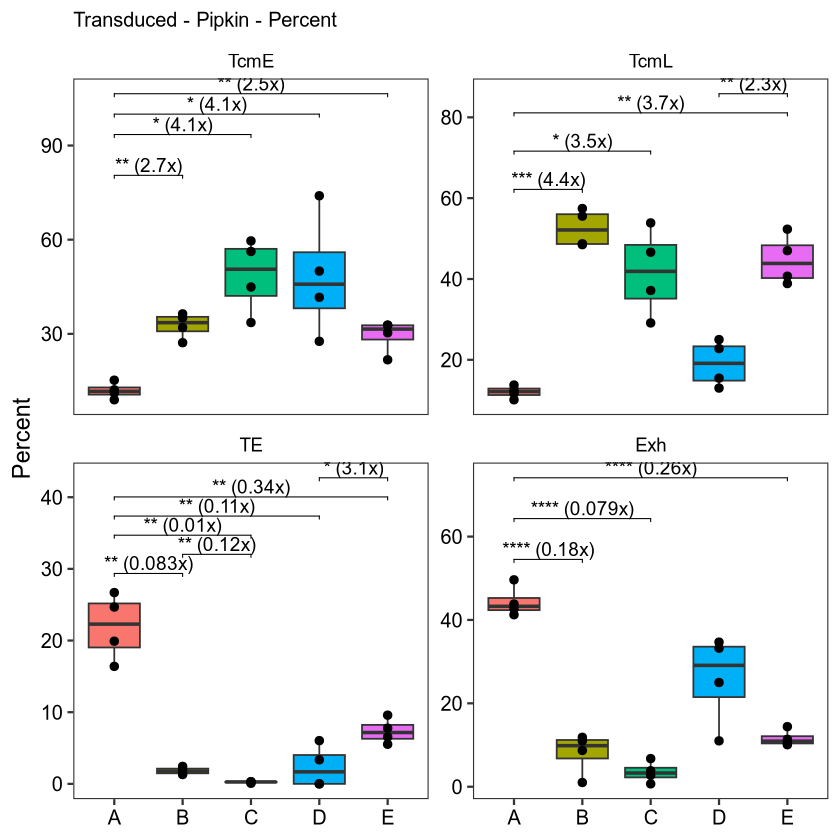

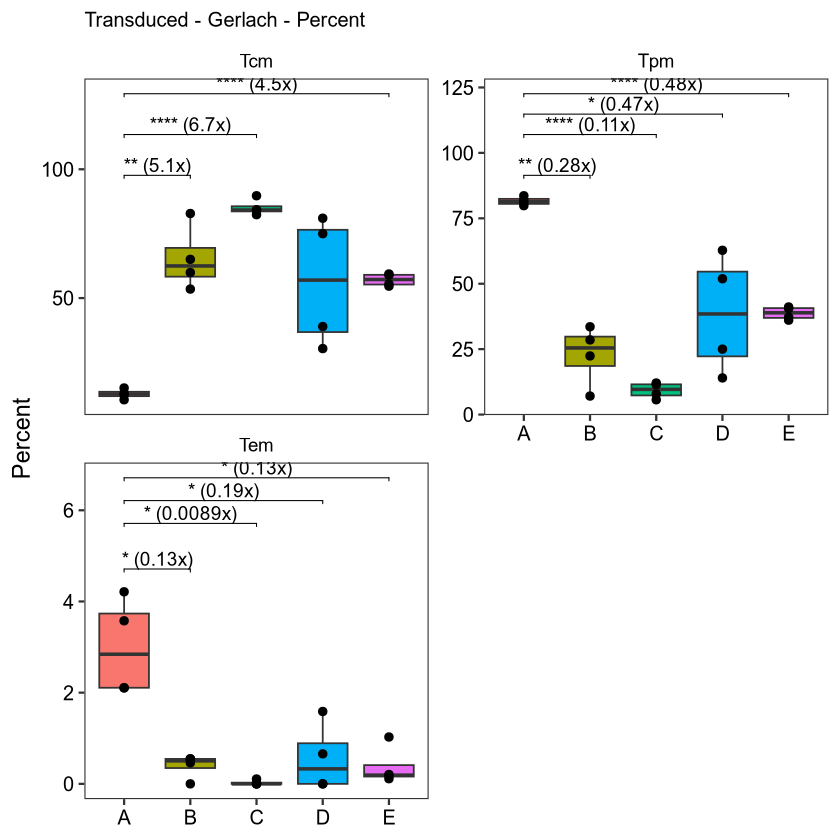

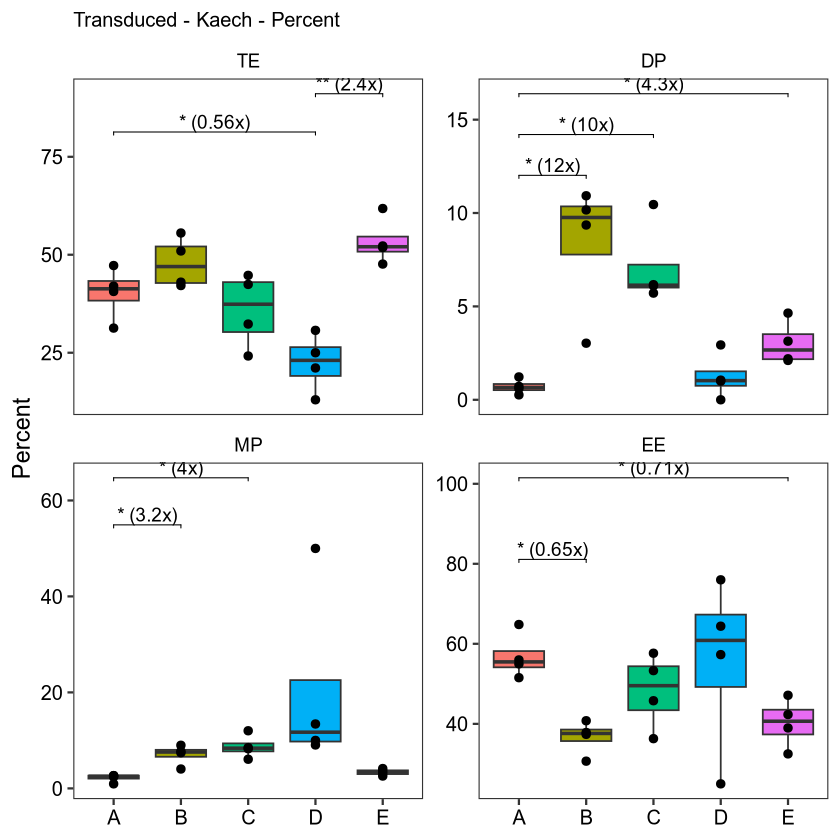

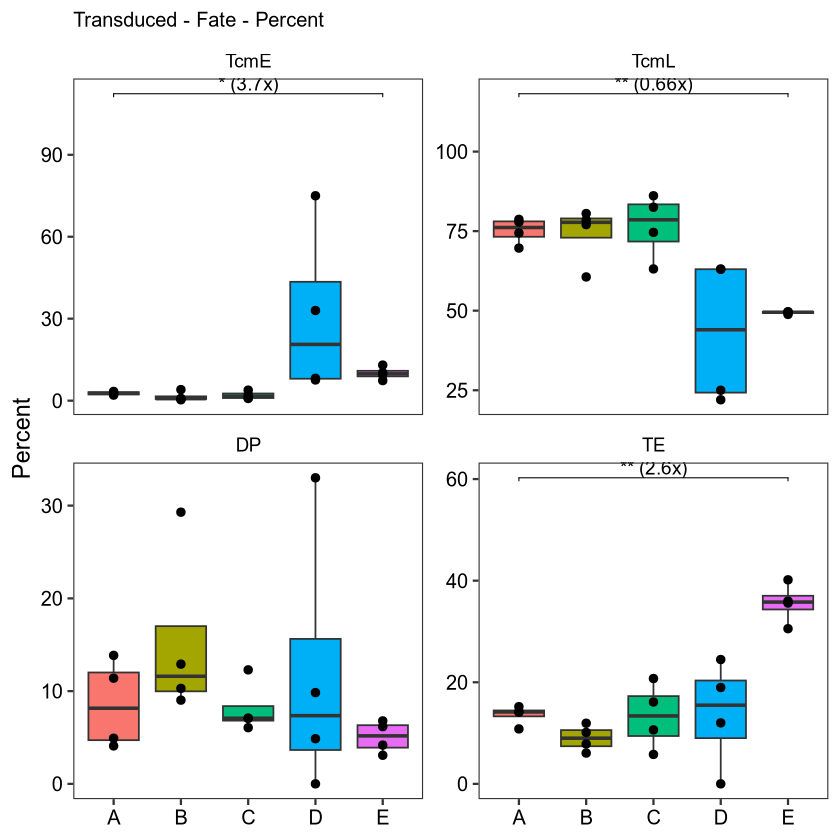

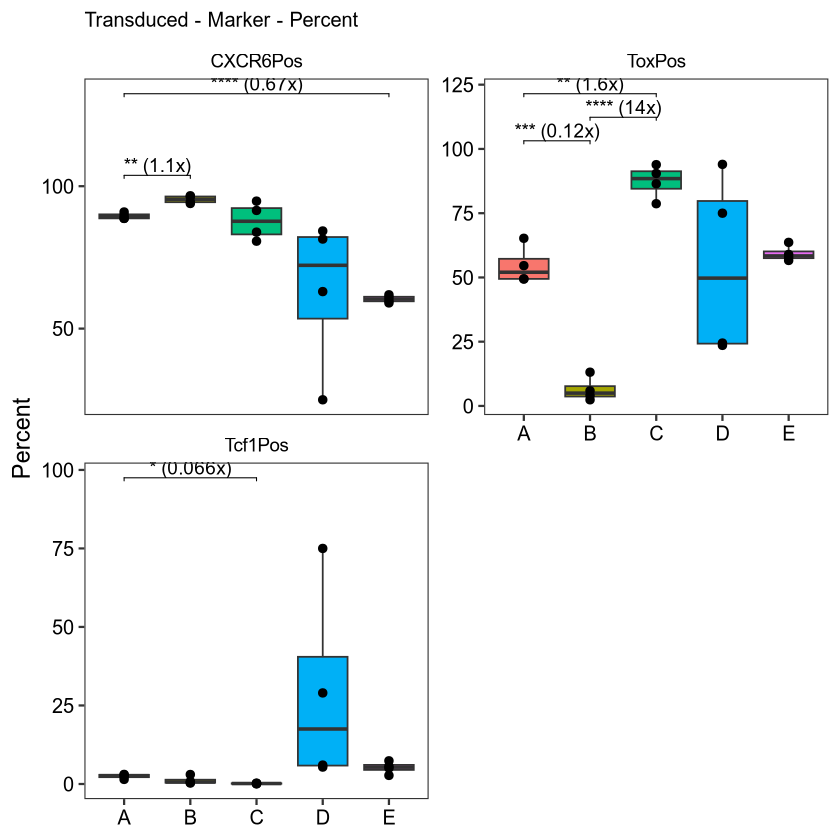

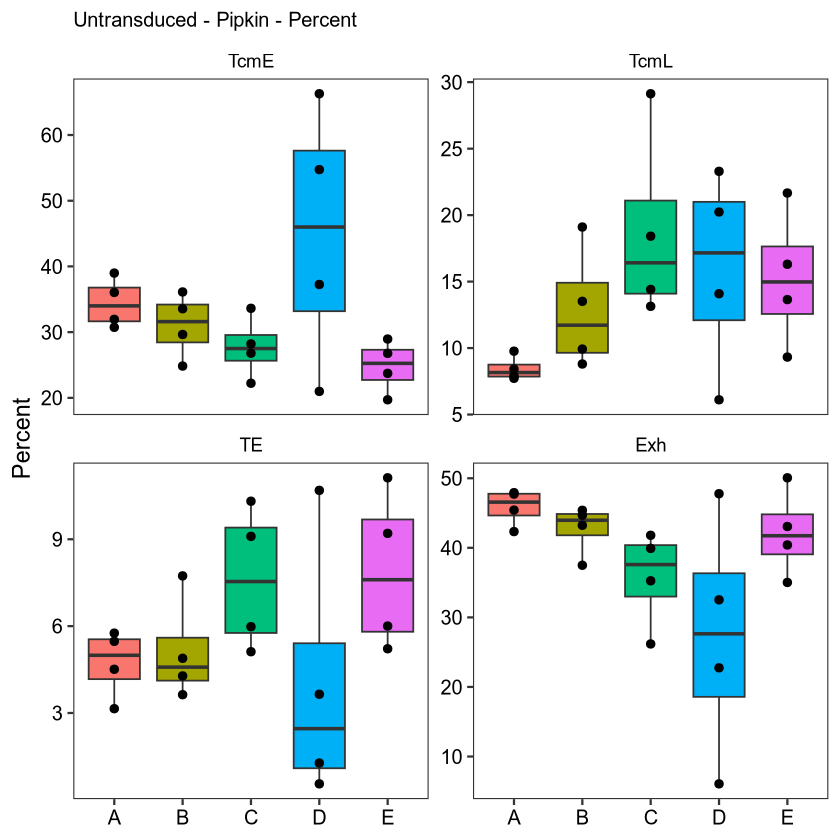

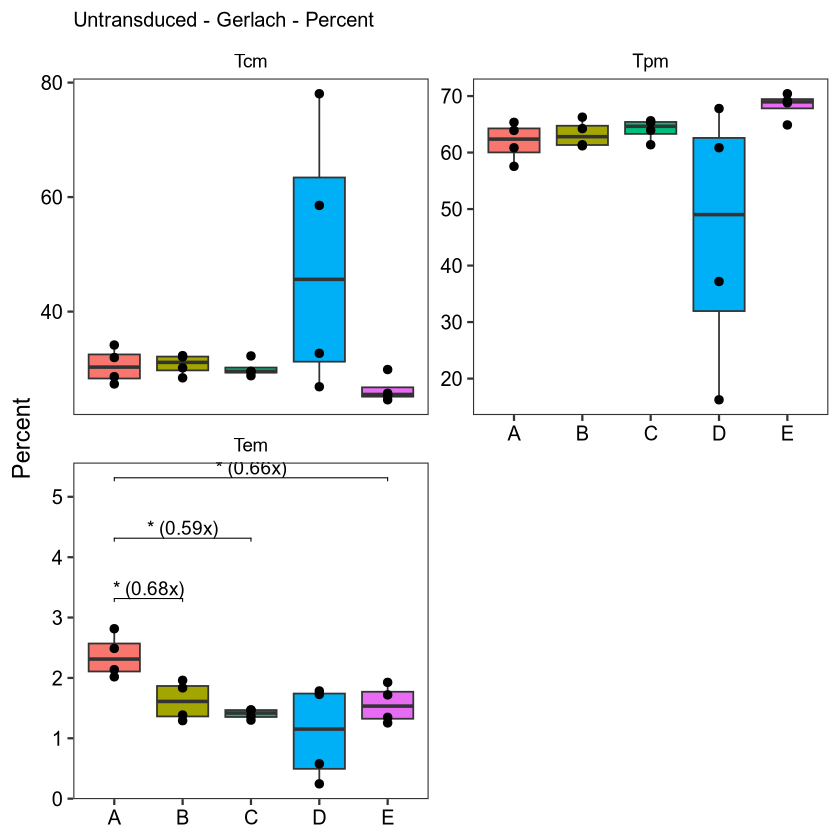

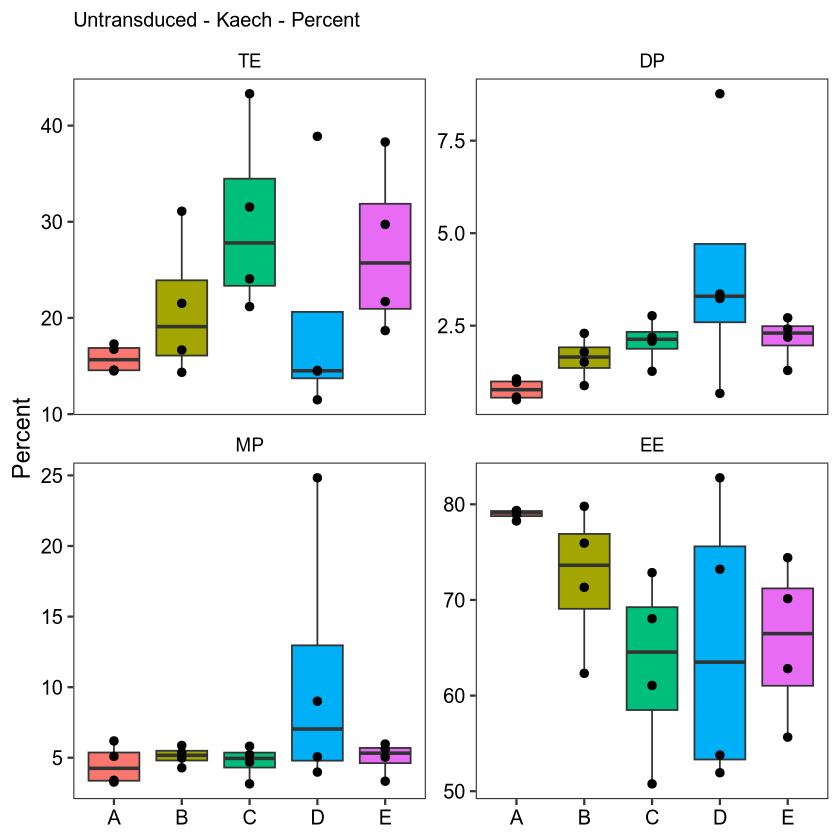

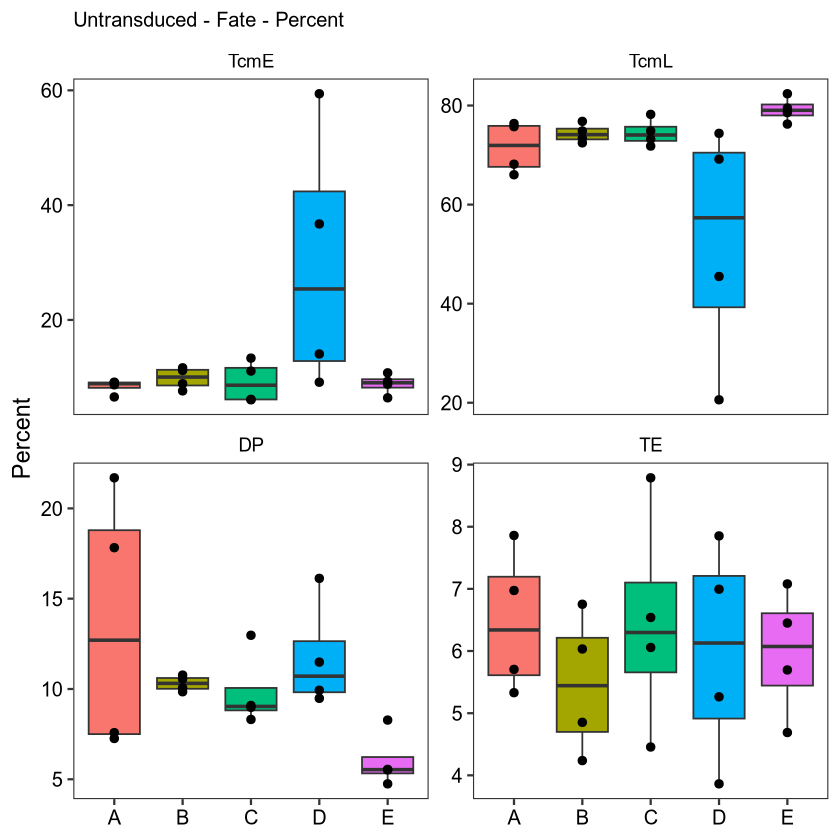

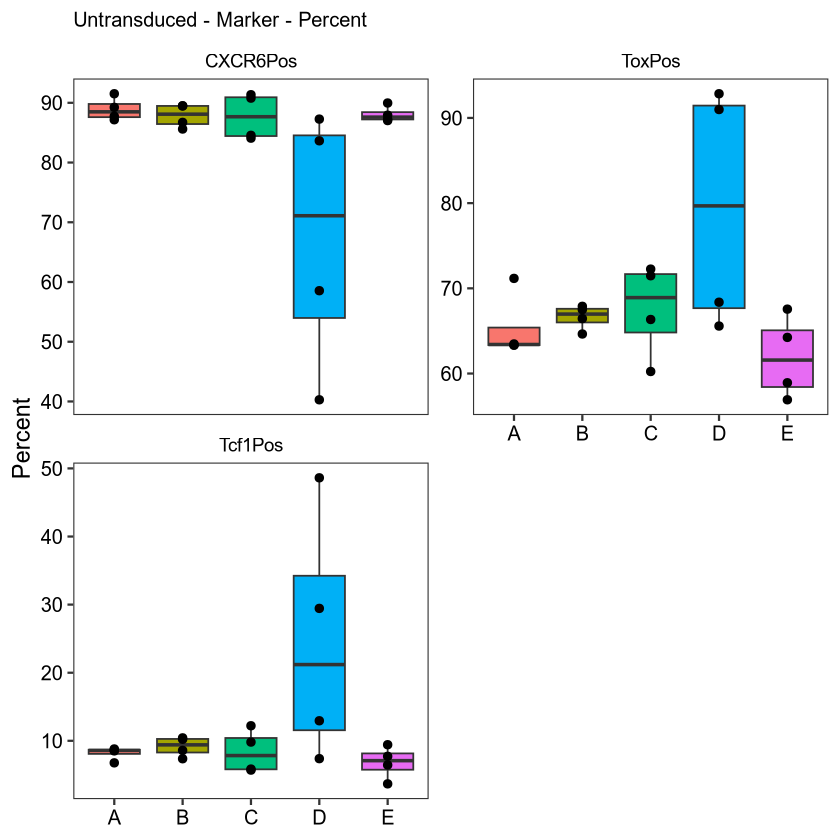

In [13]:
plotOnLoopPopulation <- function(transductions, p.schemas, y_axis, output_tag) {
    p.schemas.names <- names(p.schemas)

    # Loop on all transduction groups
    for(trans in transductions) {

        # Loop on all schemas on the Population level    
        for(schema in p.schemas.names) {

            # Select only Population with "Schema-" schema with no Population1Deriv
            # Keep only trans
            plot.data.df <- all.data %>%
                mutate(
                    Population = ifelse(Population == "all", "all-all",
                        ifelse(Population %in% c("CXCR6Pos", "ToxPos", "Tcf1Pos"), paste("Marker", Population, sep = "-"),
                            Population
                        )
                    )
                ) %>%
                filter(
                    Transduction == trans,
                    is.na(Population1Deriv),
                    grepl(paste0(schema, "-"), Population)
                ) %>%
                mutate(
                    Population = factor( 
                        gsub(paste0(schema, "-"), "", Population),
                        levels = p.schemas[[schema]]
                    ),
                    Group = factor(Group, levels = d.schemas[["Group"]])
                )
            
            # Calculate p-values and adjusted p-values for comparisons using plot_padj function
            # Skip this iteration gracefully if plot_padj fails
            plot.stat.df <- tryCatch(
                plot_padj(
                    data = plot.data.df,
                    comparisons = comparison_groups,
                    y_col = y_axis,
                    x_col = "Group",
                    facet_col = "Population",
                    step_fraction = 0.1,
                    min_step = 0.5
                ),
                error = function(e) {
                    message(sprintf(
                        "Skipping %s - %s - %s: plot_padj failed: %s",
                        trans, schema, output_tag, conditionMessage(e)
                    ))
                    NULL
                }
            )

            if (is.null(plot.stat.df)) {
                next
            }

            # Save plot.stat.df to a CSV file for inspection
            write.csv(plot.stat.df, paste0(
                output_folder,
                "/stats-",
                trans, "-", schema, "-", output_tag,
                ".csv"))

            # Round plot.stat.df column foldmean to one significant digit
            # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
            plot.stat.df <- plot.stat.df %>%
                mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
                mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

            p <- ggplot(plot.data.df, aes(x = Group, y = .data[[y_axis]], fill = Group)) +
                geom_boxplot(outlier.shape = NA) +
                geom_point(size = 2) +
                facet_wrap(~Population, ncol = 2, scales = "free_y") +
                theme +
                stat_pvalue_manual(
                    plot.stat.df %>% filter(p.adj < 0.05),
                    label = "p.adj.fold",   # adjusted p-value stars
                    tip.length = 0.01,
                    size = 4,
                    inherit.aes = FALSE       # important fix
                ) + ggtitle(paste0(trans, " - ", schema, " - ", y_axis))

            print(p)

            ggsave(
                filename = paste0(
                    output_folder,
                    "/plots-",
                    trans, "-", schema, "-", output_tag,
                    ".pdf"),
                plot = p,
                width = 10,
                height = 10,
                units = "in"
            )

        }

    }

}

plotOnLoopPopulation(transductions, p.schemas, y_axis = "Percent", output_tag = "percentOFparents")

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Skipping Transduced - Gerlach - TOXmfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `t.test.default()`:
! not enough 'y' observations

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
War

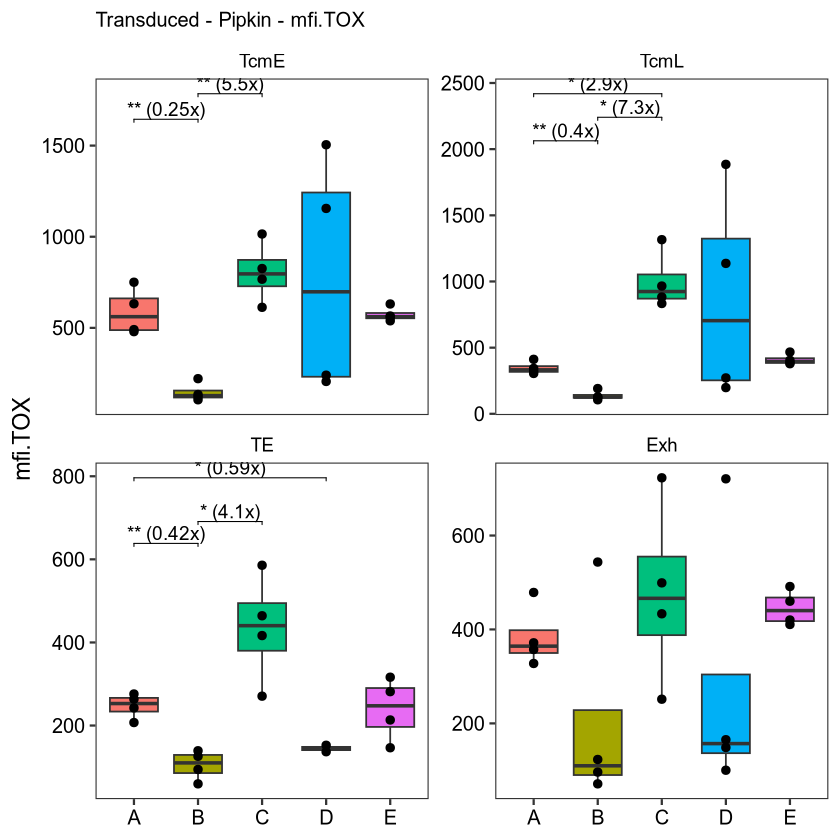

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


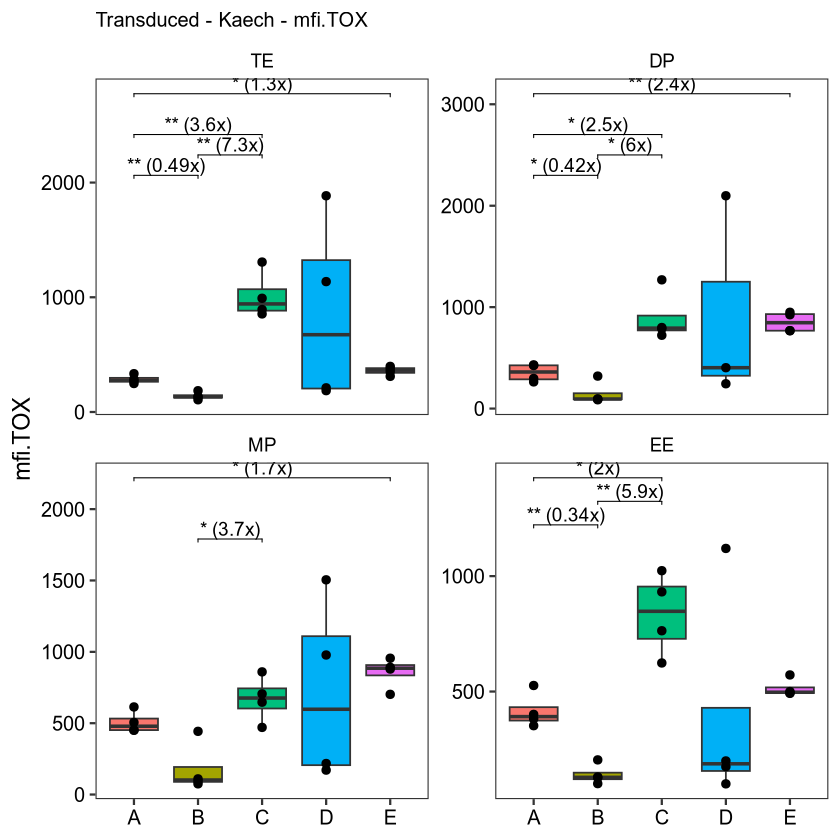

Skipping Transduced - Marker - TOXmfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 3.
Caused by error in `map()`:
ℹ In index: 1.
Caused by error in `t.test.default()`:
! not enough 'x' observations



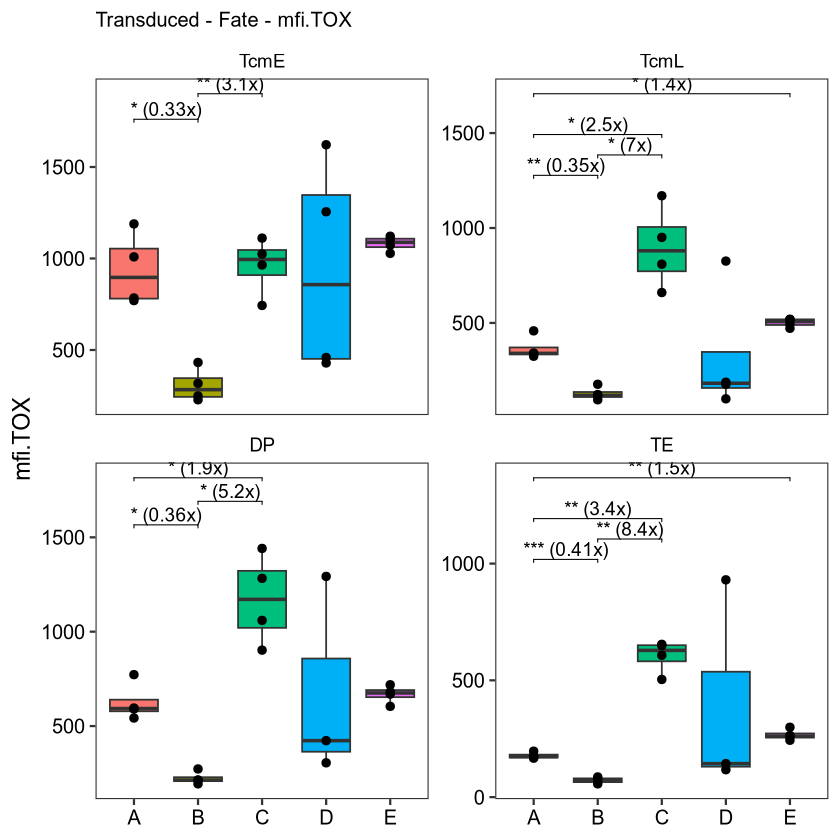

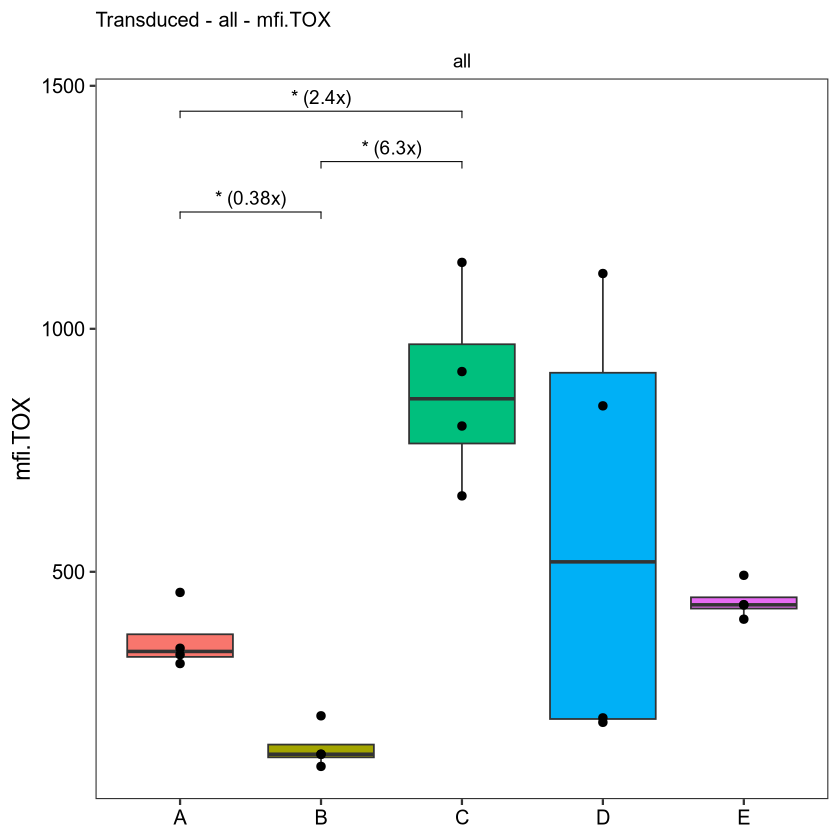

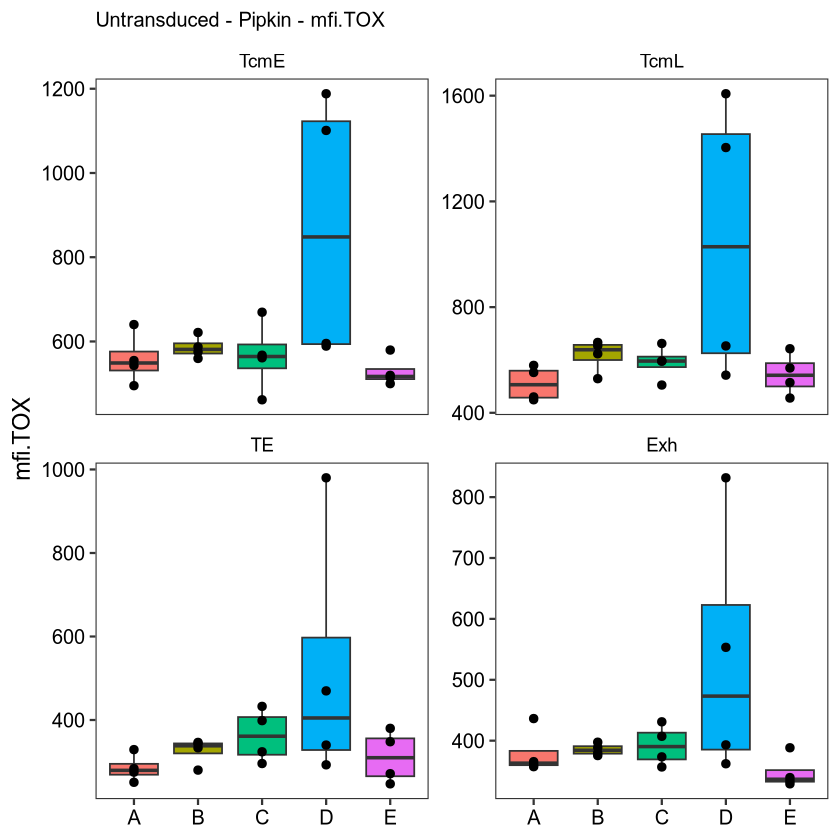

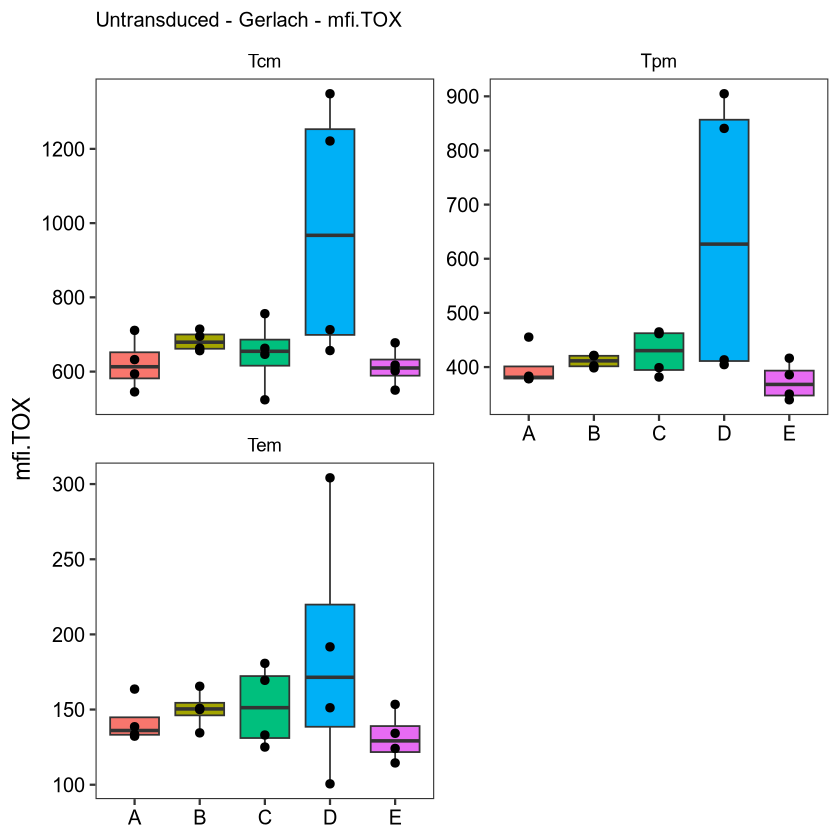

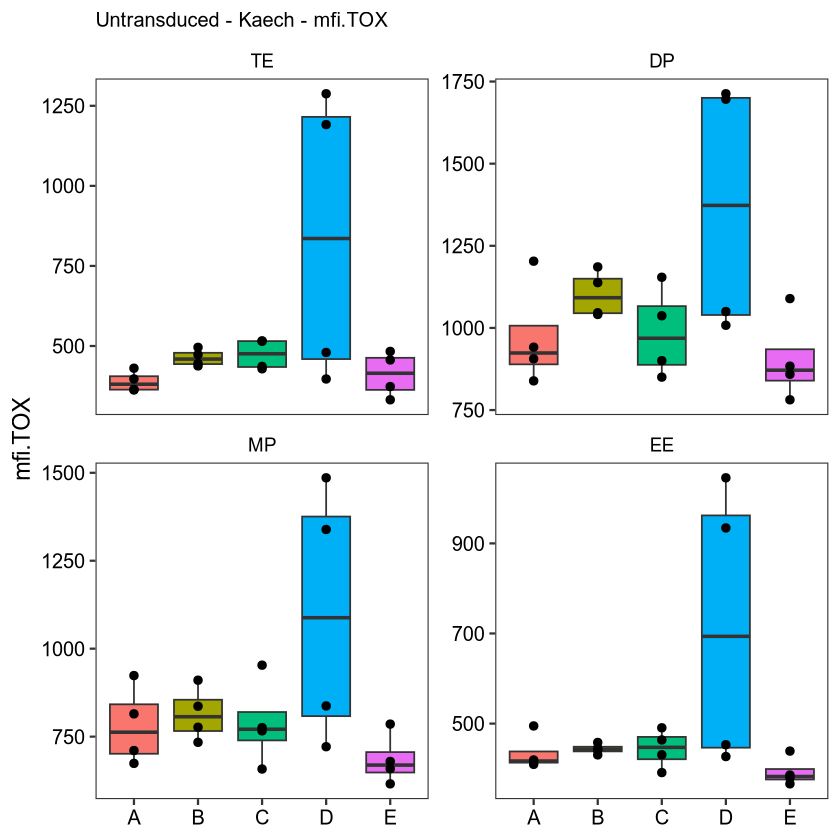

Skipping Untransduced - Marker - TOXmfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 3.
Caused by error in `map()`:
ℹ In index: 1.
Caused by error in `t.test.default()`:
! not enough 'x' observations



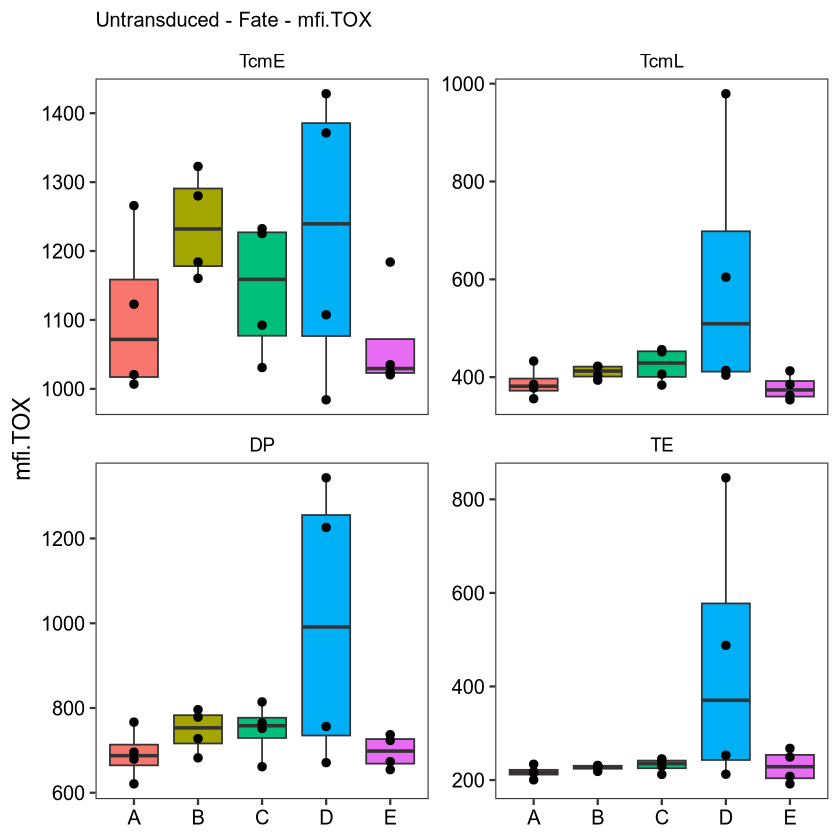

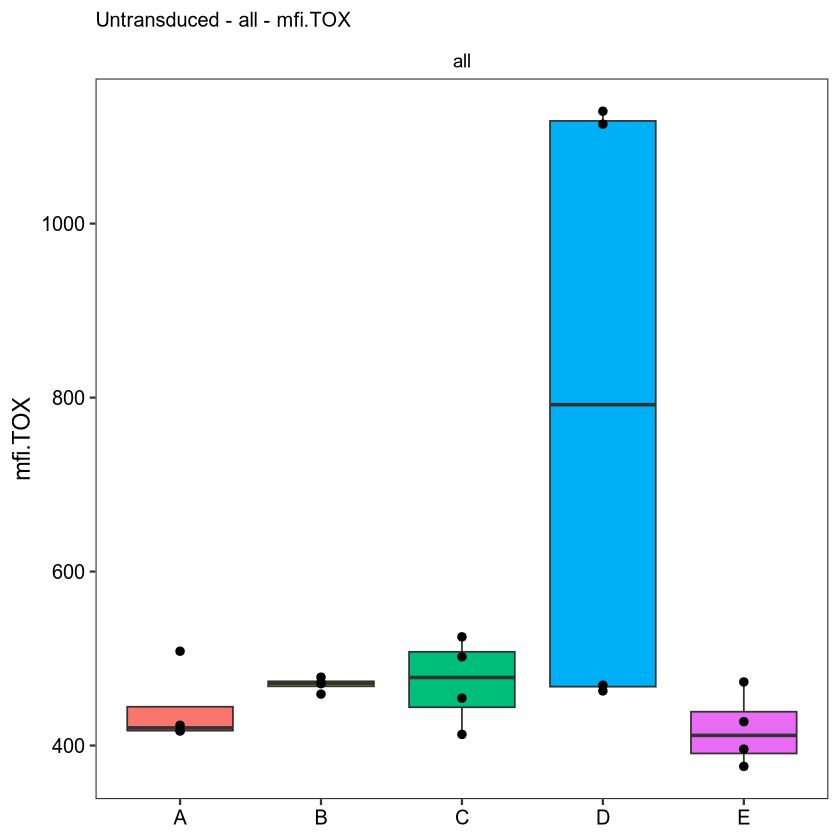

In [14]:
plotOnLoopPopulation(transductions, c(p.schemas, list(all = c("all"))), y_axis = "mfi.TOX", output_tag = "TOXmfi")

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Skipping Transduced - Gerlach - PD1mfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `t.test.default()`:
! not enough 'y' observations

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
War

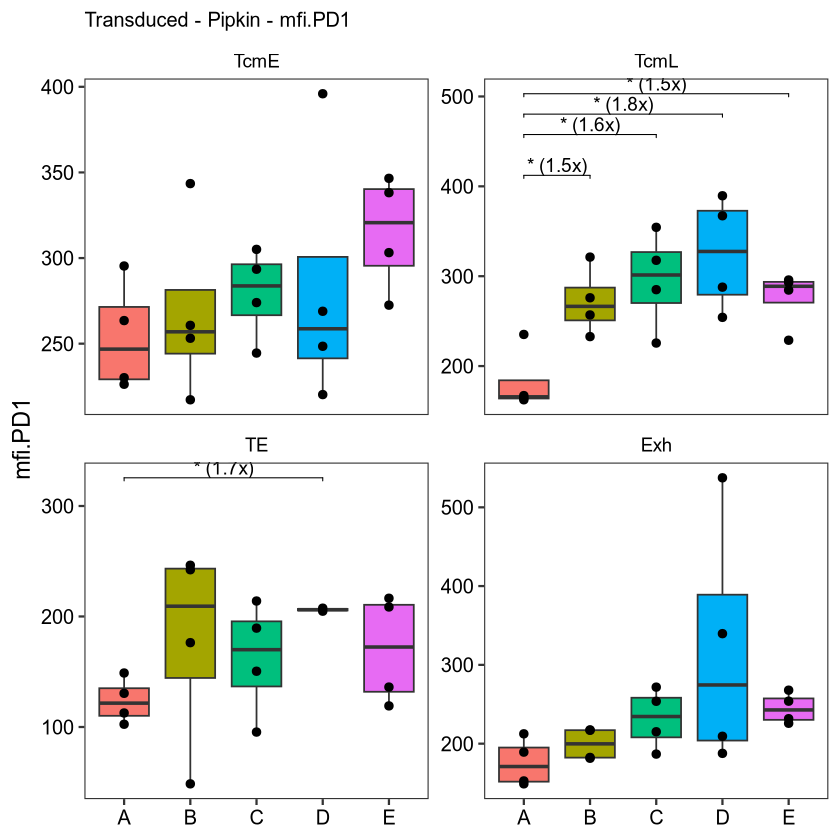

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


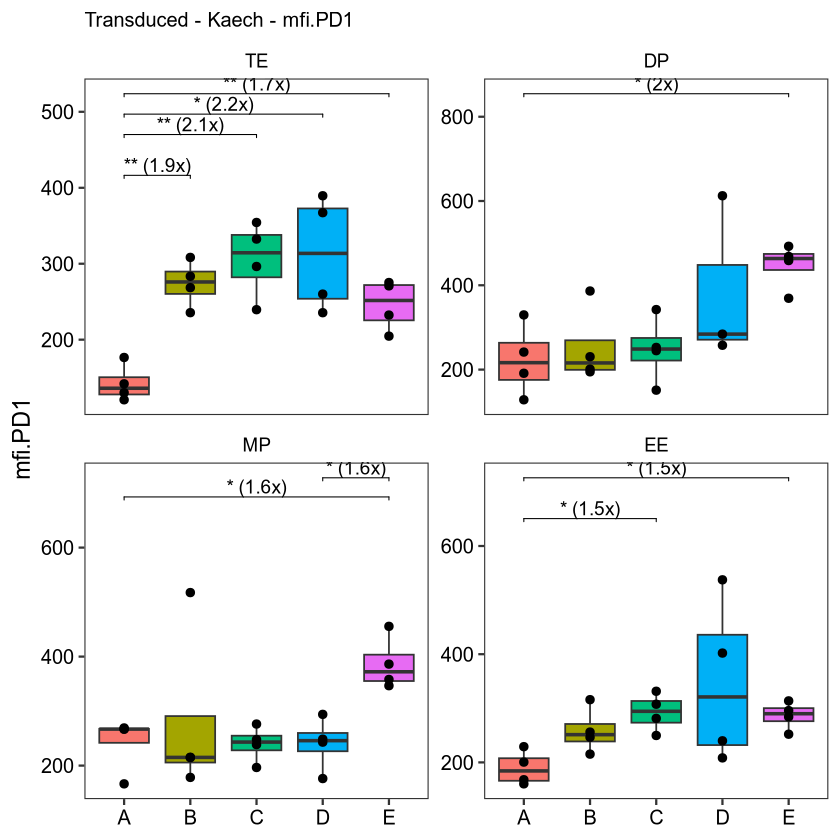

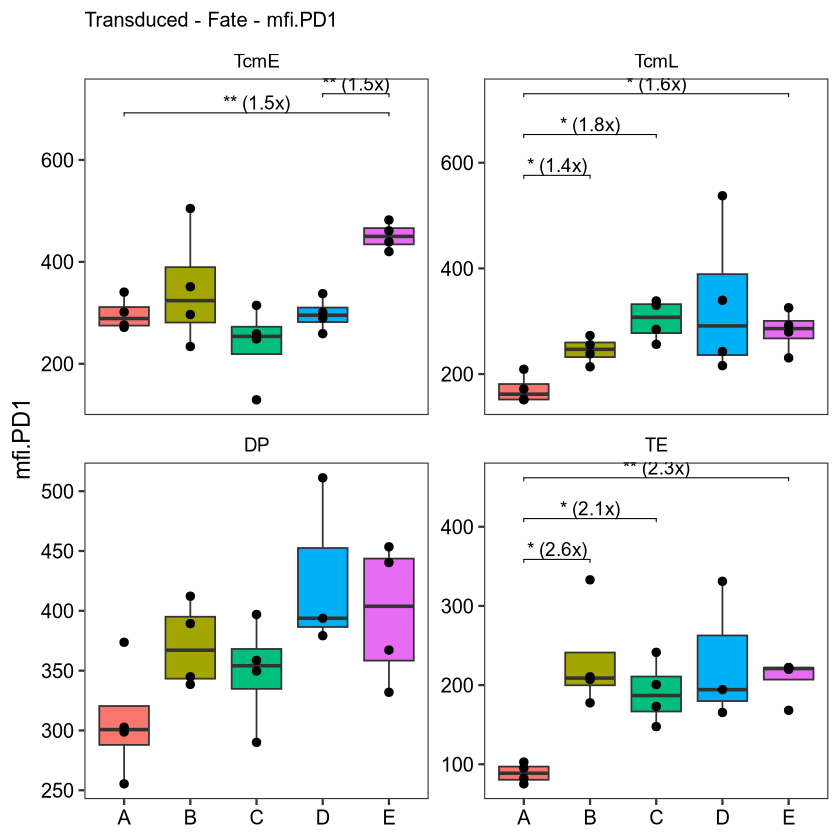

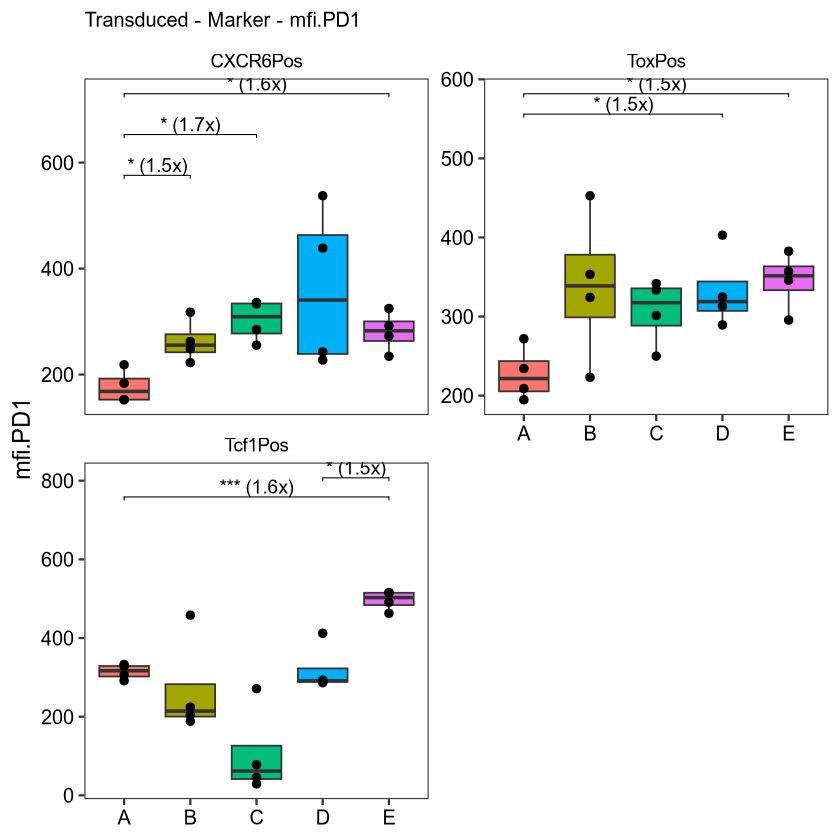

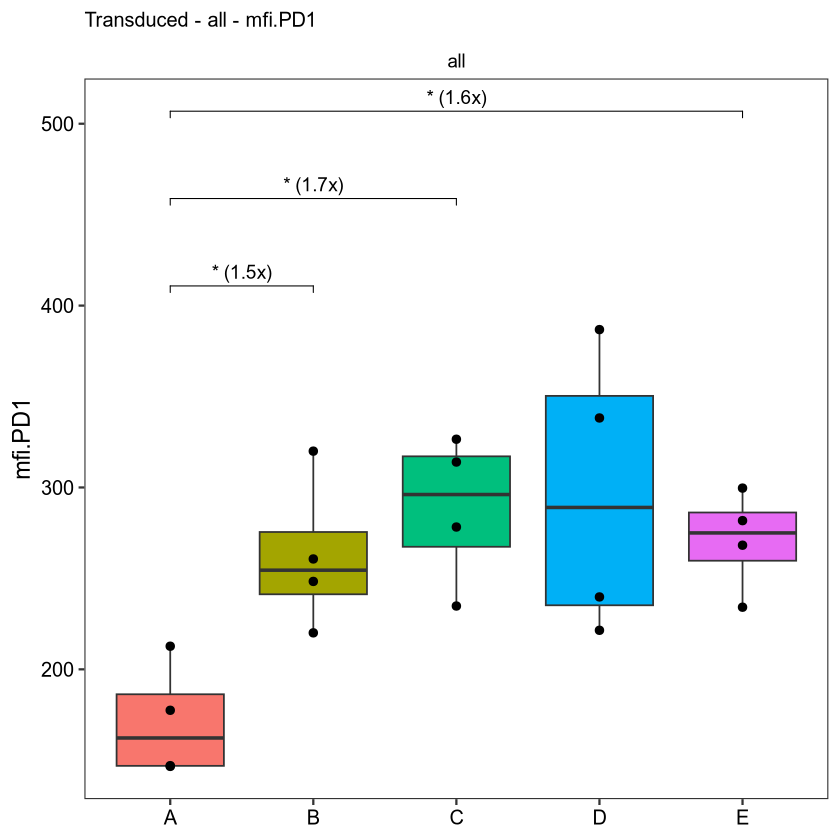

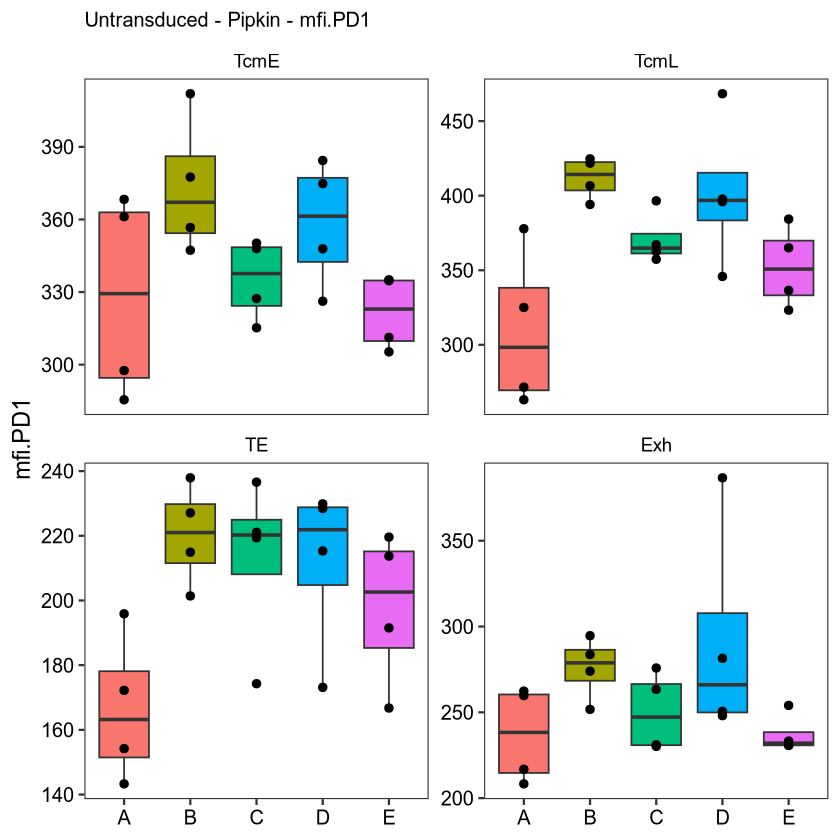

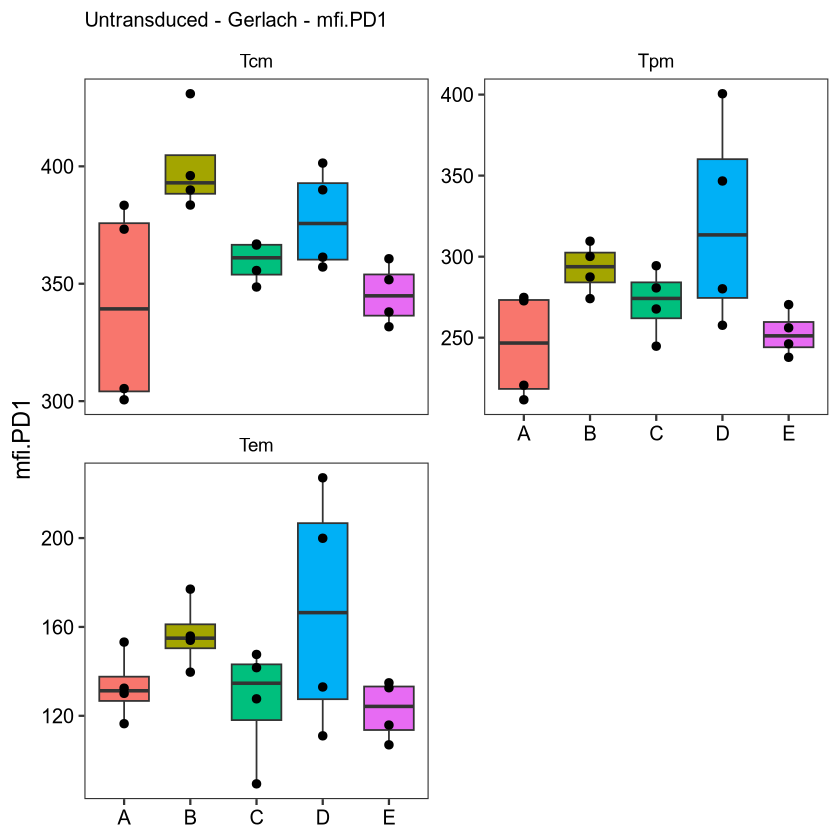

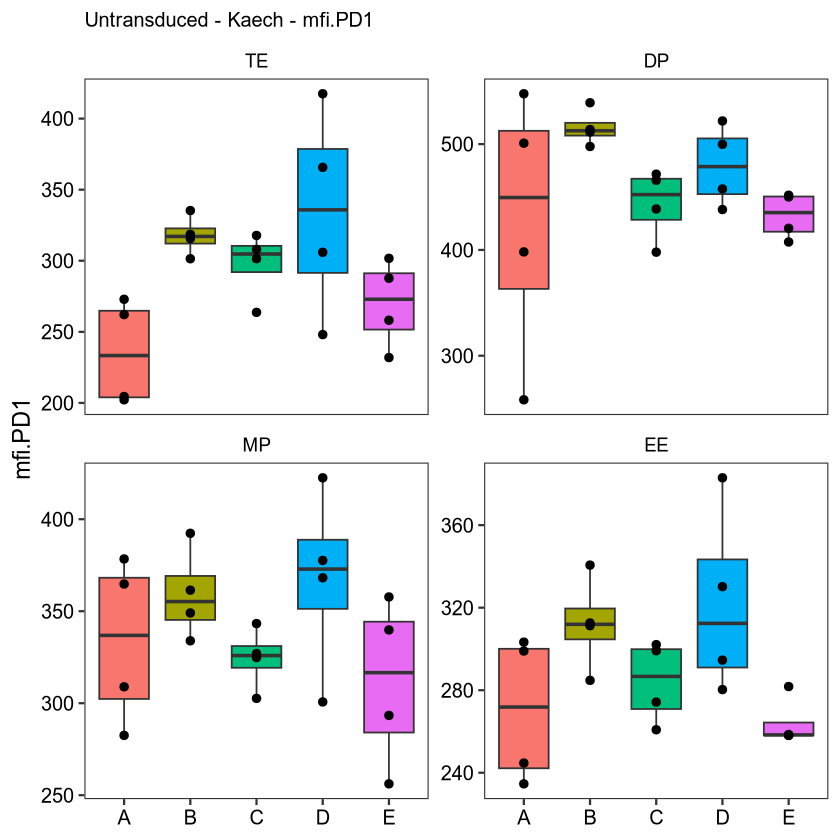

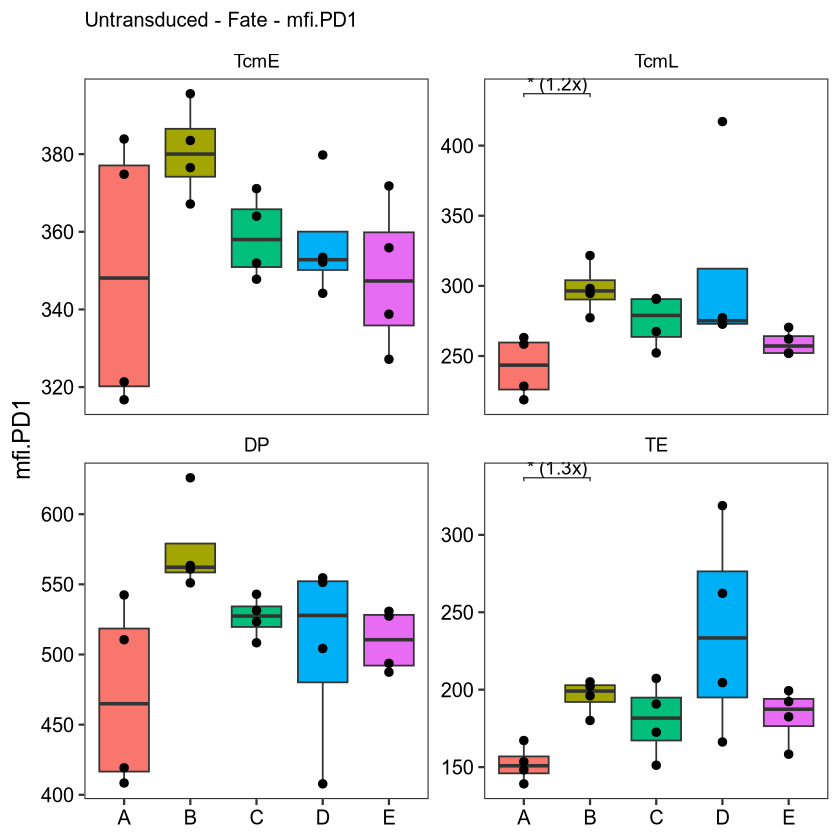

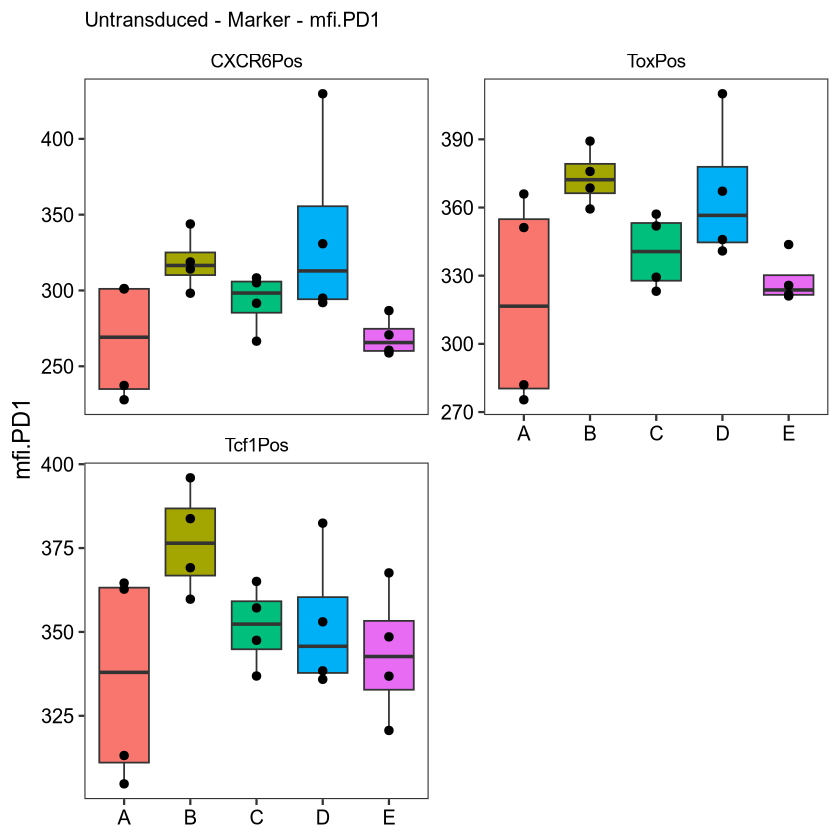

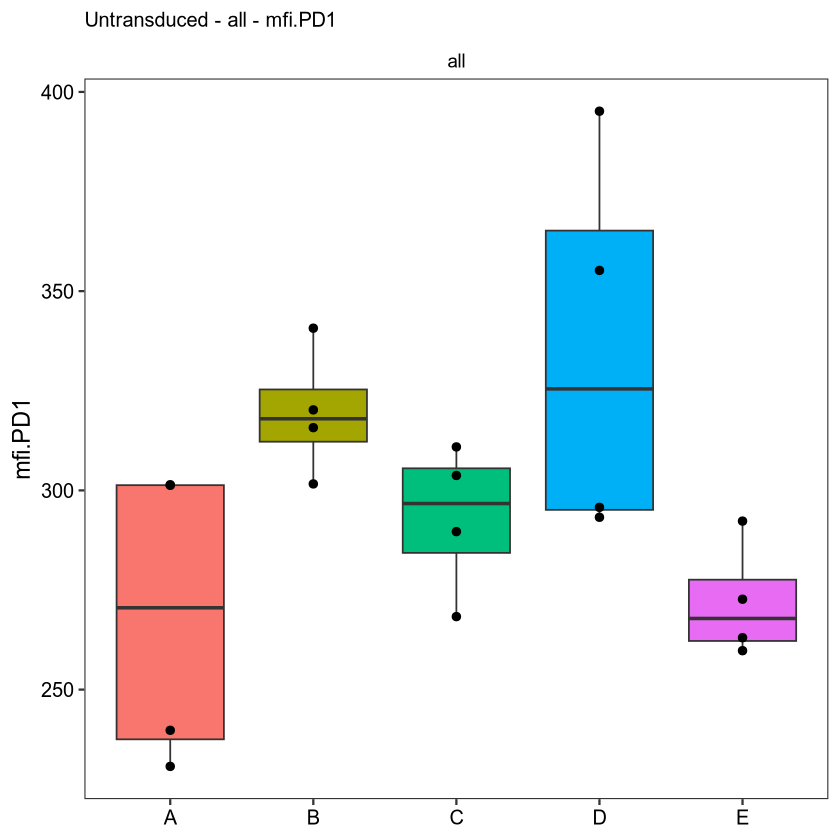

In [15]:
plotOnLoopPopulation(transductions, c(p.schemas, list(all = c("all"))), y_axis = "mfi.PD1", output_tag = "PD1mfi")